# Visualize Spectrum Reconstructions & Redshift Predictions

Load a trained transformer checkpoint (Approach A or B) plus the frozen spectrum tokenizer it was trained with, run it on a handful of DESI spectra, and visualize:

1. **Teacher-forced reconstruction** — predicted spectrum tokens decoded back through the tokenizer
2. **Autoregressive generation** — `model.generate()` from `[SOS]` only, no teacher forcing (the honest visualization)
3. **Redshift prediction** — predicted bin → decoded z value vs true z (scatter)
4. **Per-position token accuracy** — heatmap showing which positions in the sequence the model is good at
5. **Reconstruction error distribution** — per-spectrum MSE histogram

Set the paths in the **Configuration** cell, then run all cells top-to-bottom.

## Imports

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO))

import json
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.models.transformer import (
    SpectrumTransformer,
    SOS_TOKEN, EOS_TOKEN,
    SPECTRUM_TOKEN_OFFSET, REDSHIFT_TOKEN_OFFSET, TOTAL_VOCAB_SIZE,
)
from src.tokenizers.spectrum import SpectrumTokenizer, N_TOKENS
from src.tokenizers.redshift import RedshiftTokenizer
from src.training.sequences import tokenize_and_build
from src.utils.data import DESISpectrumDataset

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.facecolor'] = 'white'

## Configuration

**Official release checkpoints** live under `checkpoints/release/` (from W&B project `redshifty`). See `MANIFEST.json` for model IDs and provenance.

```bash
git lfs pull
# or rebuild symlinks from local W&B downloads:
python scripts/setup_release_checkpoints.py
```

Default model: `approach_a_fm_v1_10k_a_ddp4_redmask50_v9` + `spectrum_tokenizer_v1`.

Optional W&B pull cells below are deprecated — use release paths unless re-downloading.

### Settings

In [2]:
# Official release checkpoints (see checkpoints/release/MANIFEST.json)
from src.inference.release import (
    RELEASE_ROOT,
    DEFAULT_TRANSFORMER_ID,
    load_release_models,
    load_manifest,
    get_device,
)

MODEL_ID = DEFAULT_TRANSFORMER_ID
DATA_DIR = REPO / 'data/desi_raw'
MANIFEST_PATH = None        # optional: training JSONL for z_tok fallback only
APPROACH = None             # auto-detect from checkpoint
N_SAMPLES = 6
SEED = 42
ENCODER_MASK_RATIO = 0.0

manifest = load_manifest()
print(f'Release root: {RELEASE_ROOT}')
print(f'Model ID:     {MODEL_ID}')
print(f'DATA_DIR:     {DATA_DIR}')
print(f'APPROACH:     {APPROACH!r} (auto-detect if None)')

def _require_ckpt():
    from src.inference.release import _checkpoint_path
    try:
        _checkpoint_path(MODEL_ID)
        _checkpoint_path(manifest['models'][MODEL_ID]['requires_tokenizer'])
        return True
    except FileNotFoundError as e:
        print(f'Missing checkpoint: {e}')
        print('  git lfs pull')
        print('  python scripts/setup_release_checkpoints.py')
        return False

HAS_CKPT = _require_ckpt()
HAS_DATA = DATA_DIR.is_dir() and bool(list(DATA_DIR.glob('coadd-*.fits')))
if not HAS_DATA:
    print(f'Note: no FITS in {DATA_DIR} — visualization cells will skip (see data/README.md).')

Release root: /Users/jonathansamuel/projects/cs-686-dl/FoundationModel/checkpoints/release
Model ID:     transformer_approach_a_fm_v1_10k_ddp4_rw10_v8
DATA_DIR:     /Users/jonathansamuel/projects/cs-686-dl/FoundationModel/data/desi_raw
APPROACH:     None (auto-detect if None)


In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'device = {device}')

device = mps


## (Optional) List W&B runs & their model artifacts

Discover what's available before downloading. Lists every run in the project (most recent first) with state, best val loss, and any uploaded model artifacts (with versions and aliases). Copy any artifact URI from the printout into `ARTIFACT_URI` below.

Set `WANDB_ENTITY` to your wandb username; project is `redshifty` by default.

In [4]:
WANDB_ENTITY = 'jjayaseelan-university-of-san-francisco'  # or None for default entity
WANDB_PROJECT = 'redshifty'
MAX_RUNS = 20

try:
    from dotenv import load_dotenv
    load_dotenv(REPO / '.env')
except ImportError:
    pass
import wandb
api = wandb.Api()
path = f'{WANDB_ENTITY}/{WANDB_PROJECT}' if WANDB_ENTITY else WANDB_PROJECT
runs = api.runs(path, per_page=MAX_RUNS)
print(f'\n=== runs in {path} (most recent first) ===\n')
for r in list(runs)[:MAX_RUNS]:
    best = r.summary.get('val/loss') or r.summary.get('val_loss') or '-'
    print(f'{r.name:50s}  state={r.state:10s}  best_val_loss={best}')
    try:
        arts = list(r.logged_artifacts())
    except Exception as e:
        arts = []
        print(f'    (could not list artifacts: {e})')
    for a in arts:
        if a.type != 'model':
            continue
        uri = f'{a.entity}/{a.project}/{a.name}'
        aliases = ','.join(a.aliases) if a.aliases else ''
        size_mb = a.size / 1e6 if a.size else 0
        print(f'    -> {uri:60s}  aliases=[{aliases}]  {size_mb:.0f} MB')

print('\nCopy a `... /artifact_name:version` URI into ARTIFACT_URI below.')
print('Use :best, :latest, or :v0/:v1/... to pin a specific version.')

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.



=== runs in jjayaseelan-university-of-san-francisco/redshifty (most recent first) ===

approach_a_52827566_replay                          state=finished    best_val_loss=0.1169476766884327
approach_b_52827575_replay                          state=finished    best_val_loss=0.020094967801123857
tokenizer_v1_52693687_replay                        state=finished    best_val_loss=-
approach_a_52840231                                 state=finished    best_val_loss=23.834872999191283
approach_b_52840234                                 state=finished    best_val_loss=221.5471453857422
approach_a_52846595                                 state=crashed     best_val_loss=51.65985530853271
approach_b_52846605                                 state=crashed     best_val_loss=242.61753448486328
phase10_mask50_a                                    state=killed      best_val_loss=194.27292388916015
phase10_mask50_b                                    state=failed      best_val_loss=225.87556701660156
  

## (Optional) Pull checkpoints from W&B Artifacts

Skip the `scp` step entirely by pulling the trained transformer **and/or** the frozen spectrum tokenizer straight from W&B.

- **Transformer** — the Phase-10+ training loop uploads on every best-val step (see `--push-wandb-artifact`). Pick a URI from the run-listing cell above.
- **Spectrum tokenizer** — uploaded once with `nersc/push_tokenizer_artifact.py` (run on NERSC after pretraining finishes). Typical URI: `<entity>/redshifty/spectrum_tokenizer_v1:best`.

Leave a URI as `None` to use the locally-set path instead.

In [5]:
ARTIFACT_URI           = None  # transformer; e.g. 'jonathansamuel/redshifty/approach_a_<run>:best'
TOKENIZER_ARTIFACT_URI = None  # tokenizer;   e.g. 'jonathansamuel/redshifty/spectrum_tokenizer_v1:best'

if ARTIFACT_URI is not None or TOKENIZER_ARTIFACT_URI is not None:
    try:
        from dotenv import load_dotenv
        load_dotenv(REPO / '.env')
    except ImportError:
        pass
    import wandb
    api = wandb.Api()

    def _pull(uri, label):
        art = api.artifact(uri, type='model')
        dl_dir = REPO / 'checkpoints' / 'wandb_artifacts' / uri.replace('/', '__').replace(':', '@')
        dl_dir.mkdir(parents=True, exist_ok=True)
        art.download(root=str(dl_dir))
        pts = sorted(dl_dir.glob('*.pt'))
        assert pts, f'No .pt file in artifact {uri}'
        print(f'[wandb] {label}: downloaded {uri} -> {pts[0]}')
        return pts[0]

    if ARTIFACT_URI is not None:
        _pull(ARTIFACT_URI, 'transformer')
        print('Re-run: python scripts/setup_release_checkpoints.py')
    if TOKENIZER_ARTIFACT_URI is not None:
        _pull(TOKENIZER_ARTIFACT_URI, 'tokenizer')
        print('Re-run: python scripts/setup_release_checkpoints.py')
else:
    print('[wandb] both URIs None; using checkpoints/release/')

[wandb] both URIs None; using checkpoints/release/


## Load release models

Loads `approach_a_fm_v1_10k_a_ddp4_redmask50_v9` + `spectrum_tokenizer_v1` from `checkpoints/release/`.

In [4]:
if not HAS_CKPT:
    raise RuntimeError('Release checkpoints missing — see Configuration cell.')

model, spec_tok, z_tok, cfg = load_release_models(MODEL_ID, device=device)
ckpt_z_state = None

if APPROACH is None:
    APPROACH = cfg.get('approach', 'a')
print(f"Loaded {cfg.get('display_name', MODEL_ID)}")
print(f'  approach={APPROACH!r}  d_model={cfg.get("d_model")}')
n_params = sum(p.numel() for p in model.parameters())
print(f'  transformer params: {n_params/1e6:.1f}M')
print(f'  z_tok: n_levels={z_tok.n_levels}  range=[{z_tok._min_z:.4f}, {z_tok._max_z:.4f}]')

Loaded Spectrum-FM Transformer — Approach A (encoder sees z)
  approach='a'  d_model=768
  transformer params: 100.1M
  z_tok: n_levels=256  range=[-0.0019, 5.6568]


## Redshift tokenizer fallback (optional)

Release load already restores `z_tok` from the transformer checkpoint. The cells below only run if that failed.

In [5]:
if z_tok is not None:
    print('[z_tok] using embedded state from release checkpoint')
elif MANIFEST_PATH is not None and Path(MANIFEST_PATH).is_file():
    from astropy.io import fits
    zs = []
    with open(MANIFEST_PATH) as f:
        for line in f:
            rec = json.loads(line)
            try:
                with fits.open(rec['redrock'], memmap=True) as h:
                    z = h['REDSHIFTS'].data['Z']
                    zwarn = h['REDSHIFTS'].data['ZWARN']
                    zs.append(z[zwarn == 0].astype('float32'))
            except Exception as e:
                print(f'  skip {rec["redrock"]}: {e}')
    zs = torch.from_numpy(np.concatenate(zs))
    z_tok = RedshiftTokenizer(n_levels=256)
    z_tok.fit(zs)
    print(f'[z_tok] fit from manifest  n={len(zs)}  '
          f'range=[{zs.min():.4f}, {zs.max():.4f}]')

[z_tok] using embedded state from release checkpoint


## Load spectra to visualize

Reuses `DESISpectrumDataset` from `src/utils/data.py` to load FITS files from `DATA_DIR`. If `z_tok` is still uninitialized at this point, fits it on these spectra as a last resort (and prints a warning).

In [6]:
if not HAS_DATA:
    print(f'No FITS in {DATA_DIR}. Downloading 2 healpix tiles...')
    import subprocess
    subprocess.run(
        [sys.executable, str(REPO / 'scripts/download_desi_batch.py'), '--n-files', '2'],
        check=False, cwd=str(REPO),
    )
    HAS_DATA = DATA_DIR.is_dir() and bool(list(DATA_DIR.glob('coadd-*.fits')))
    if not HAS_DATA:
        raise RuntimeError(
            f'No FITS in {DATA_DIR}. Run from repo root:\n'
            '  python scripts/download_desi_batch.py --n-files 2'
        )
coadd_files = sorted(DATA_DIR.glob('coadd-*.fits'))
print(f'Found {len(coadd_files)} coadd files in {DATA_DIR}')

spectra = []
for f in coadd_files:
    rr = f.parent / f.name.replace('coadd-', 'redrock-')
    if not rr.exists():
        print(f'  skip {f.name}: no redrock counterpart')
        continue
    ds = DESISpectrumDataset(
        coadd_path=f, redrock_path=rr,
        require_good_zwarn=True, require_nonzero_flux=True,
    )
    for i in range(len(ds)):
        spectra.append(ds[i])
print(f'Loaded {len(spectra)} good spectra')

if z_tok is None:
    print('\n*** WARNING: z_tok was not loaded from checkpoint or manifest. ***')
    print('*** Fitting on local FITS spectra. Predicted z values may be miscalibrated ***')
    print('*** relative to what the trained model expects. ***\n')
    z_values_fallback = torch.tensor([float(s['z']) for s in spectra])
    z_tok = RedshiftTokenizer(n_levels=256)
    z_tok.fit(z_values_fallback)
    print(f'[z_tok] fit from local FITS  n={len(z_values_fallback)}')

print(f'\n[z_tok] in use: n_levels={z_tok.n_levels}  '
      f'range=[{z_tok._min_z:.4f}, {z_tok._max_z:.4f}]')

Found 2 coadd files in /Users/jonathansamuel/projects/cs-686-dl/FoundationModel/data/desi_raw
  Filtered out 18 bad spectra:
    18 bad fiber status
Loaded 25 good spectra from coadd-sv3-bright-10016.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
  Filtered out 1 bad spectra:
    1 bad ZWARN
Loaded 4 good spectra from coadd-sv3-bright-10145.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
Loaded 29 good spectra

[z_tok] in use: n_levels=256  range=[-0.0019, 5.6568]


## Pick samples to visualize

In [7]:
rng = torch.Generator().manual_seed(SEED)
idx = torch.randperm(len(spectra), generator=rng)[:N_SAMPLES].tolist()
sample_specs = [spectra[i] for i in idx]
for i, s in enumerate(sample_specs):
    print(f'  sample {i}: z={float(s["z"]):+.4f}  L={len(s["flux"])} pixels')

  sample 0: z=+0.1146  L=7781 pixels
  sample 1: z=+0.3228  L=7781 pixels
  sample 2: z=+0.1153  L=7781 pixels
  sample 3: z=+0.2007  L=7781 pixels
  sample 4: z=+0.9900  L=7781 pixels
  sample 5: z=+0.2766  L=7781 pixels


## Helpers

In [38]:
def specs_to_batch(spec_list):
    """Pad a list of spectrum dicts to a uniform tensor batch."""
    L = max(s['flux'].shape[0] for s in spec_list)
    def _pad(t, fill=0.0):
        if t.shape[0] == L: return t
        out = torch.full((L,), fill, dtype=t.dtype)
        out[:t.shape[0]] = t
        return out
    return {
        'flux': torch.stack([_pad(s['flux']) for s in spec_list]),
        'ivar': torch.stack([_pad(s['ivar'], 0.0) for s in spec_list]),
        'z':    torch.stack([s['z'] for s in spec_list]).float(),
    }

@torch.no_grad()
def predict_teacher_forced(batch, approach):
    """Returns (enc, dec, target, predicted_tokens, denorm). predicted_tokens
    has the same shape as target — model's argmax at every decoder position."""
    enc, dec, tgt, _ = tokenize_and_build(
        batch, spec_tok, z_tok, approach, device, encoder_mask_ratio=ENCODER_MASK_RATIO,
    )
    logits, _ = model(enc, dec, targets=tgt)
    pred = logits.argmax(dim=-1)
    flux = batch['flux'].to(device)
    ivar = batch['ivar'].to(device)
    istd = torch.sqrt(ivar.clamp(min=1e-10))
    x = torch.stack([flux, istd], dim=1)
    _, denorm = spec_tok.encode(x)
    return enc, dec, tgt, pred, denorm

@torch.no_grad()
def predict_autoregressive(batch, approach, temperature=1.0):
    enc, _, tgt, _ = tokenize_and_build(
        batch, spec_tok, z_tok, approach, device, encoder_mask_ratio=ENCODER_MASK_RATIO,
    )
    L_dec = tgt.shape[1]
    generated = model.generate(
        enc, decoder_start_token=SOS_TOKEN, max_new_tokens=L_dec,
        temperature=temperature,
    )
    return generated, tgt

def decode_to_flux(spec_token_ids, denorm):
    """Map global vocab token IDs (with SPECTRUM_TOKEN_OFFSET) back through
    the spectrum tokenizer to a continuous flux array. Invalid token IDs
    (SOS/EOS/MASK leakage) are mapped to LFQ index 0 so decode doesn't crash."""
    lfq_idx = spec_token_ids - SPECTRUM_TOKEN_OFFSET
    valid = (lfq_idx >= 0) & (lfq_idx < 1024)
    lfq_idx = torch.where(valid, lfq_idx, torch.zeros_like(lfq_idx))
    decoded = spec_tok.decode(lfq_idx, denorm)
    return decoded[:, 0]  # flux channel

# ── Spectral line marker ──────────────────────────────────────────────────────
EMISSION_LINES = {
    'Lyα':        1216,
    '[OII]':      3727,
    'Hδ':         4102,
    'Hγ':         4340,
    'Hβ':         4861,
    '[OIII]4959': 4959,
    '[OIII]5007': 5007,
    'Hα':         6563,
    '[NII]':      6583,
    '[SII]':      6717,
}
ABSORPTION_LINES = {
    'CaK':  3934,
    'CaH':  3968,
    'G':    4300,
    'Mgb':  5175,
    'NaD':  5893,
    'CaT':  8542,
}

def mark_lines(ax, z, wave_lo, wave_hi, wave_to_x=None, ypos=0.97, fontsize=6.5):
    """Overlay redshifted emission (green dashed) and absorption (orange dotted) lines.

    wave_lo/wave_hi : observed wavelength limits (Angstrom) for visibility check.
    wave_to_x       : converts observed wavelength to x-axis units; None = wavelength IS x.
    """
    if wave_to_x is None:
        wave_to_x = lambda w: w
    trans = ax.get_xaxis_transform()   # x in data coords, y in axes [0,1]
    for label, lam in EMISSION_LINES.items():
        obs = lam * (1 + z)
        if not (wave_lo <= obs <= wave_hi):
            continue
        x = wave_to_x(obs)
        ax.axvline(x, color='green', lw=0.6, ls='--', alpha=0.45)
        ax.text(x, ypos, label, transform=trans, fontsize=fontsize,
                color='green', rotation=90, va='top', ha='right', alpha=0.85)
    for label, lam in ABSORPTION_LINES.items():
        obs = lam * (1 + z)
        if not (wave_lo <= obs <= wave_hi):
            continue
        x = wave_to_x(obs)
        ax.axvline(x, color='darkorange', lw=0.6, ls=':', alpha=0.45)
        ax.text(x, ypos, label, transform=trans, fontsize=fontsize,
                color='darkorange', rotation=90, va='top', ha='right', alpha=0.85)


## Visualization 1 — Teacher-forced reconstruction

Each row: one sample. Black = original (after tokenizer roundtrip); orange = decoded from the model's predicted tokens. Teacher-forced means the decoder saw the ground-truth tokens at every position before the one it predicted, so this is the **best-case** reconstruction (and the most copy-inflated).

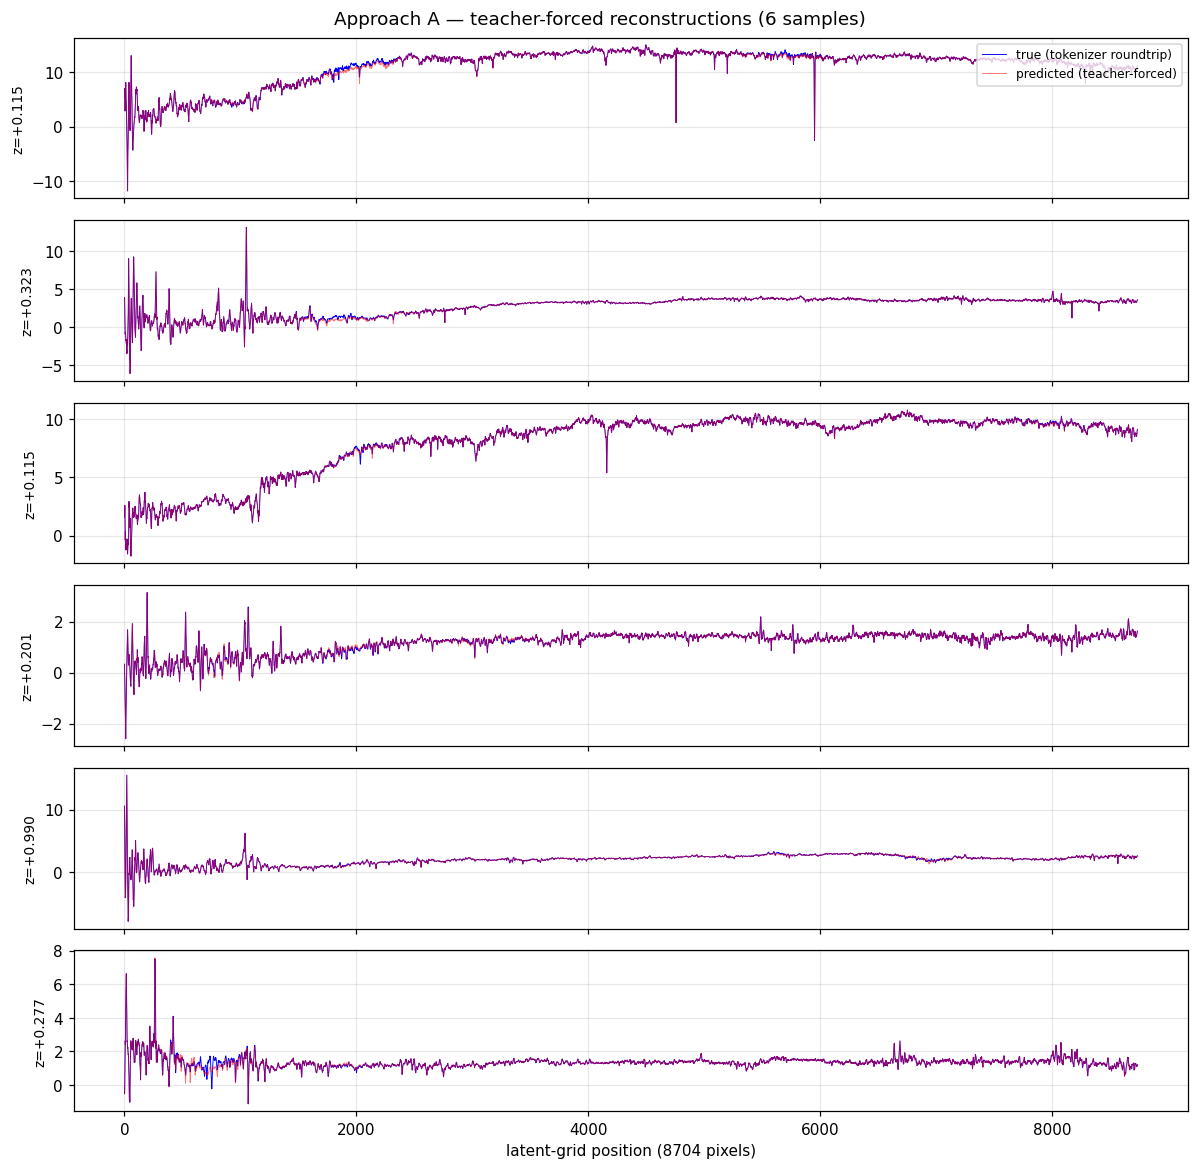

In [11]:
batch = specs_to_batch(sample_specs)
enc, dec, tgt, pred, denorm = predict_teacher_forced(batch, APPROACH)

pred_spec_tokens = pred[:, 1:1 + N_TOKENS]
true_spec_tokens = tgt[:, 1:1 + N_TOKENS]

pred_flux = decode_to_flux(pred_spec_tokens, denorm).cpu().numpy()
true_flux = decode_to_flux(true_spec_tokens, denorm).cpu().numpy()

fig, axes = plt.subplots(N_SAMPLES, 1, figsize=(11, 1.8 * N_SAMPLES), sharex=True)
if N_SAMPLES == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(true_flux[i], color='blue', lw=0.6, label='true (tokenizer roundtrip)')
    ax.plot(pred_flux[i], color='red', lw=0.6, alpha=0.55, label='predicted (teacher-forced)')
    z = float(sample_specs[i]['z'])
    _dec_len = true_flux.shape[1]
    mark_lines(ax, z, 3600, 9824,
               wave_to_x=lambda w: (w - 3600) / (9824 - 3600) * (_dec_len - 1))
    ax.set_ylabel(f'z={z:+.3f}', fontsize=9)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('latent-grid position')
fig.suptitle(f'Approach {APPROACH.upper()} — teacher-forced reconstructions ({N_SAMPLES} samples)')
fig.tight_layout()
plt.show()

## Visualization 2 — Autoregressive generation

Same samples, but generated token-by-token starting from `[SOS]` only. **No peeking at the answer.** This is the honest reconstruction — if it looks similar to teacher-forced, the model really learned. If it diverges, the teacher-forced number was inflated by the cross-attention copy.

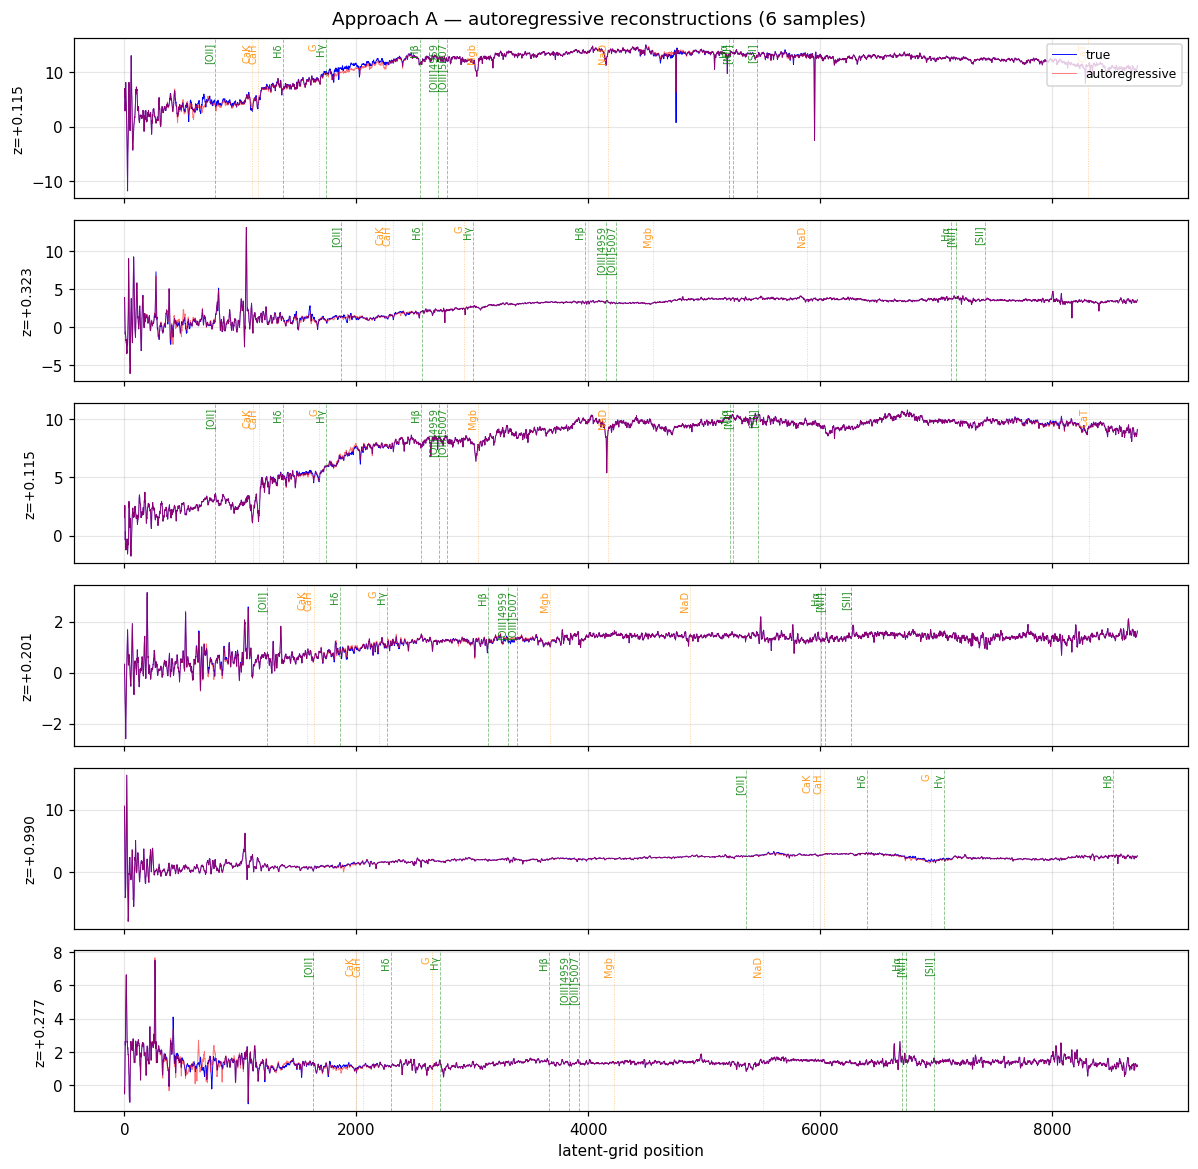

In [39]:
generated, tgt_ar = predict_autoregressive(batch, APPROACH, temperature=1.0)
ar_spec_tokens = generated[:, 2:2 + N_TOKENS]
# Pad if generate stopped early on EOS
if ar_spec_tokens.shape[1] < N_TOKENS:
    pad_len = N_TOKENS - ar_spec_tokens.shape[1]
    pad = torch.full((ar_spec_tokens.shape[0], pad_len), SPECTRUM_TOKEN_OFFSET,
                     dtype=torch.long, device=device)
    ar_spec_tokens = torch.cat([ar_spec_tokens, pad], dim=1)

ar_flux = decode_to_flux(ar_spec_tokens, denorm).cpu().numpy()

fig, axes = plt.subplots(N_SAMPLES, 1, figsize=(11, 1.8 * N_SAMPLES), sharex=True)
if N_SAMPLES == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(true_flux[i], color='blue', lw=0.6, label='true')
    ax.plot(ar_flux[i], color='red', lw=0.6, alpha=0.55, label='autoregressive')
    z = float(sample_specs[i]['z'])
    _dec_len = ar_flux.shape[1]
    mark_lines(ax, z, 3600, 9824,
               wave_to_x=lambda w: (w - 3600) / (9824 - 3600) * (_dec_len - 1))
    ax.set_ylabel(f'z={z:+.3f}', fontsize=9)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('latent-grid position')
fig.suptitle(f'Approach {APPROACH.upper()} — autoregressive reconstructions ({N_SAMPLES} samples)')
fig.tight_layout()
plt.show()

## Visualization 3 — Redshift predictions

Predicted bin → decoded z (via the empirical-CDF inverse). For Approach A this should be near-perfect (cross-attention copy); for B it should be near random (the Phase 9 finding).

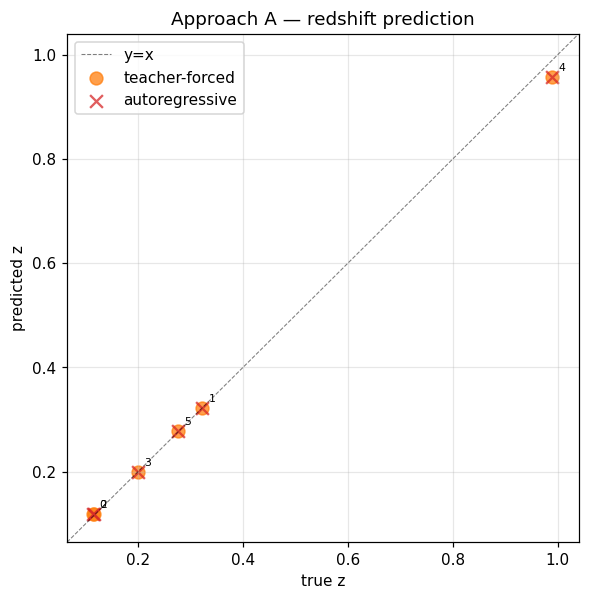


teacher-forced  MAE = 0.0069
autoregressive  MAE = 0.0069

Per-sample:
  0: z_true=+0.1146  tf=+0.1183  ar=+0.1183
  1: z_true=+0.3228  tf=+0.3230  ar=+0.3230
  2: z_true=+0.1153  tf=+0.1183  ar=+0.1183
  3: z_true=+0.2007  tf=+0.2002  ar=+0.2002
  4: z_true=+0.9900  tf=+0.9567  ar=+0.9567
  5: z_true=+0.2766  tf=+0.2775  ar=+0.2775


In [13]:
tf_z_token  = pred[:, 0].cpu()
tf_z_idx    = (tf_z_token - REDSHIFT_TOKEN_OFFSET).clamp(0, z_tok.n_levels - 1)
tf_z_pred   = torch.tensor([z_tok.decode(int(i)) for i in tf_z_idx])

ar_z_token  = generated[:, 1].cpu()
ar_z_idx    = (ar_z_token - REDSHIFT_TOKEN_OFFSET).clamp(0, z_tok.n_levels - 1)
ar_z_pred   = torch.tensor([z_tok.decode(int(i)) for i in ar_z_idx])

z_true = torch.stack([s['z'] for s in sample_specs]).float()

fig, ax = plt.subplots(figsize=(6, 6))
lim_lo = min(z_true.min().item(), tf_z_pred.min().item(), ar_z_pred.min().item()) - 0.05
lim_hi = max(z_true.max().item(), tf_z_pred.max().item(), ar_z_pred.max().item()) + 0.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=0.7, alpha=0.5, label='y=x')
ax.scatter(z_true, tf_z_pred, s=70, alpha=0.75, label='teacher-forced', c='C1')
ax.scatter(z_true, ar_z_pred, s=70, alpha=0.75, marker='x', label='autoregressive', c='C3')
for i in range(len(z_true)):
    ax.annotate(str(i), (z_true[i], tf_z_pred[i]), fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('true z')
ax.set_ylabel('predicted z')
ax.set_title(f'Approach {APPROACH.upper()} — redshift prediction')
ax.grid(alpha=0.3)
ax.legend()
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
plt.show()

print(f'\nteacher-forced  MAE = {(tf_z_pred - z_true).abs().mean():.4f}')
print(f'autoregressive  MAE = {(ar_z_pred - z_true).abs().mean():.4f}')
print(f'\nPer-sample:')
for i in range(len(z_true)):
    print(f'  {i}: z_true={z_true[i]:+.4f}  tf={tf_z_pred[i]:+.4f}  ar={ar_z_pred[i]:+.4f}')

## Visualization 4 — Per-position token accuracy

Across the batch, fraction of correct token predictions at each decoder position. Position 0 = redshift; positions 1..N = spectrum tokens. A model relying on the trivial copy shortcut will be near-flat at high accuracy on positions 1+ but near-zero at position 0.

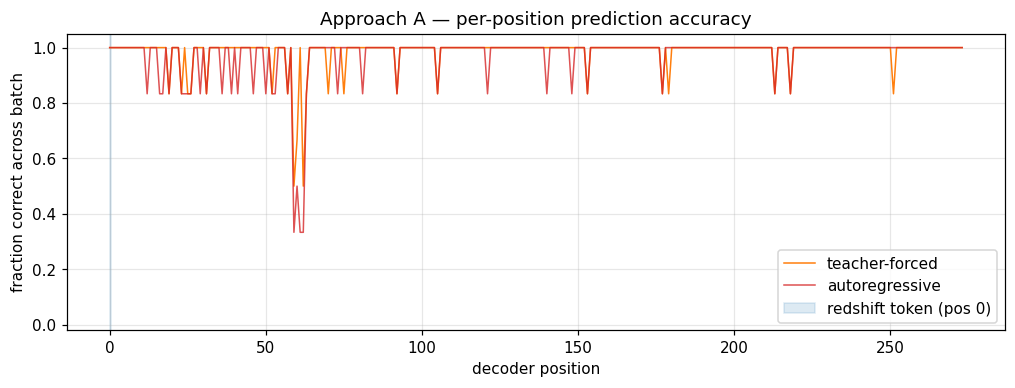

In [14]:
tf_correct = (pred == tgt).float().mean(dim=0).cpu().numpy()
ar_overlap_len = min(generated.shape[1] - 1, tgt.shape[1])
ar_correct = (generated[:, 1:1 + ar_overlap_len] == tgt[:, :ar_overlap_len]).float().mean(dim=0).cpu().numpy()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(tf_correct, label='teacher-forced', color='C1', lw=1.0)
ax.plot(ar_correct, label='autoregressive', color='C3', lw=1.0, alpha=0.8)
ax.axvspan(0, 0.5, alpha=0.15, color='C0', label='redshift token (pos 0)')
ax.set_xlabel('decoder position')
ax.set_ylabel('fraction correct across batch')
ax.set_title(f'Approach {APPROACH.upper()} — per-position prediction accuracy')
ax.set_ylim(-0.02, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Visualization 5 — Reconstruction error distribution

Per-spectrum MSE between original (tokenizer-roundtripped) and predicted flux. The AR/TF ratio is the headline — `~1.0` means the model really learned; `>>1` means teacher-forcing was carrying it.

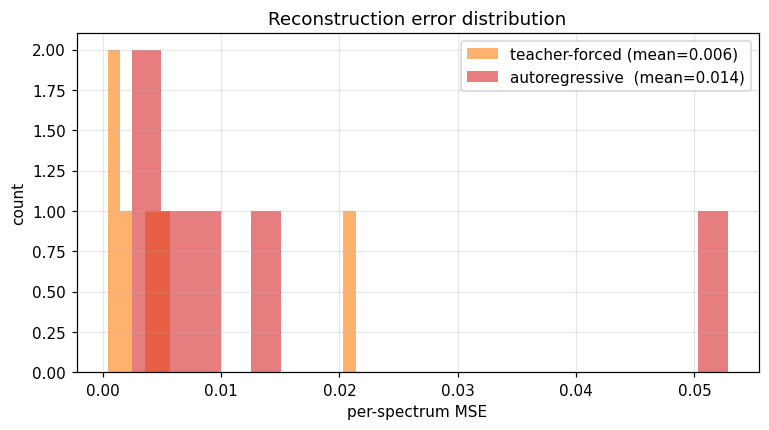

TF MSE: mean=0.006, median=0.003, max=0.021
AR MSE: mean=0.014, median=0.007, max=0.053
AR/TF ratio: 2.56x  (1.0 = identical; >>1 = AR much worse → copy shortcut)


In [15]:
tf_mse = ((torch.from_numpy(true_flux) - torch.from_numpy(pred_flux))**2).mean(dim=1).numpy()
ar_mse = ((torch.from_numpy(true_flux) - torch.from_numpy(ar_flux))**2).mean(dim=1).numpy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(tf_mse, bins=20, alpha=0.6, label=f'teacher-forced (mean={tf_mse.mean():.3f})', color='C1')
ax.hist(ar_mse, bins=20, alpha=0.6, label=f'autoregressive  (mean={ar_mse.mean():.3f})', color='C3')
ax.set_xlabel('per-spectrum MSE')
ax.set_ylabel('count')
ax.set_title('Reconstruction error distribution')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f'TF MSE: mean={tf_mse.mean():.3f}, median={np.median(tf_mse):.3f}, max={tf_mse.max():.3f}')
print(f'AR MSE: mean={ar_mse.mean():.3f}, median={np.median(ar_mse):.3f}, max={ar_mse.max():.3f}')
print(f'AR/TF ratio: {ar_mse.mean()/max(tf_mse.mean(), 1e-9):.2f}x  '
      f'(1.0 = identical; >>1 = AR much worse → copy shortcut)')

---
## OOD Probe — SDSS Spectra (Out-of-Distribution)

Load 10 SDSS DR17 spectra from [MultimodalUniverse/sdss](https://huggingface.co/datasets/MultimodalUniverse/sdss) and run the trained model on them. SDSS and DESI share broad wavelength coverage but differ in:

| | SDSS | DESI |
|---|---|---|
| Wavelength | ~3700–10,000 Å (log-λ) | 3600–9824 Å (linear) |
| Resolution | R ~ 2,000 | R ~ 3,000–5,000 |
| Fiber diameter | 3″ | 1.5″ |

Spectra are linearly interpolated onto the DESI grid before being passed through the tokenizer and transformer. Wavelength coverage gaps are filled with zero flux / zero ivar.

**Three OOD visualizations follow (autoregressive only):**
- **Viz 6** — AR reconstructions of SDSS spectra
- **Viz 7** — AR redshift prediction scatter on SDSS
- **Viz 8** — AR MSE comparison: DESI (in-dist) vs SDSS (OOD)

In [45]:
N_OOD = 10
MAX_MASK_FRAC = 0.10  # skip spectra with >10% masked pixels (bad CCD / cosmic rays)

try:
    from datasets import load_dataset
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'datasets', '-q'])
    from datasets import load_dataset


print('Streaming SDSS spectra from MultimodalUniverse/sdss ...')
sdss_ds = load_dataset(
    'MultimodalUniverse/sdss',
    split='train',
    streaming=True,
    trust_remote_code=False,
)

sdss_raw = []
n_skipped_z = 0
n_skipped_mask = 0
for row in sdss_ds:
    if row['ZWARNING']:
        n_skipped_z += 1
        continue
    z = float(row['Z'])
    if not (0.01 <= z <= 5.0):
        n_skipped_z += 1
        continue
    mask_frac = np.array(row['spectrum']['mask'], dtype=bool).mean()
    if mask_frac > MAX_MASK_FRAC:
        n_skipped_mask += 1
        continue
    sdss_raw.append(row)
    if len(sdss_raw) >= N_OOD:
        break

print(f'Collected {len(sdss_raw)} SDSS spectra  '
      f'(skipped {n_skipped_z} bad-z, {n_skipped_mask} high-mask-frac >{MAX_MASK_FRAC:.0%})')
for i, r in enumerate(sdss_raw):
    s = r['spectrum']
    lam = s['lambda']
    mf = np.array(s['mask'], dtype=bool).mean()
    print(f'  sdss {i}: z={r["Z"]:.4f}  '
          f'λ=[{min(lam):.0f}, {max(lam):.0f}] Å  '
          f'n={len(s["flux"])} px  mask={mf:.1%}')


Streaming SDSS spectra from MultimodalUniverse/sdss ...
Collected 10 SDSS spectra  (skipped 4 bad-z, 1 high-mask-frac >10%)
  sdss 0: z=0.1026  λ=[3788, 9221] Å  n=3865 px  mask=1.8%
  sdss 1: z=0.0622  λ=[3788, 9221] Å  n=3865 px  mask=1.9%
  sdss 2: z=0.1919  λ=[3788, 9221] Å  n=3865 px  mask=1.7%
  sdss 3: z=0.0800  λ=[3788, 9221] Å  n=3865 px  mask=2.0%
  sdss 4: z=0.1521  λ=[3788, 9221] Å  n=3865 px  mask=1.2%
  sdss 5: z=0.0436  λ=[3788, 9221] Å  n=3865 px  mask=0.4%
  sdss 6: z=0.0322  λ=[3788, 9221] Å  n=3865 px  mask=1.7%
  sdss 7: z=0.1355  λ=[3788, 9221] Å  n=3865 px  mask=2.2%
  sdss 8: z=0.1492  λ=[3788, 9221] Å  n=3865 px  mask=2.5%
  sdss 9: z=0.0743  λ=[3788, 9221] Å  n=3865 px  mask=1.6%


In [46]:
from scipy.interpolate import interp1d

desi_wave = spectra[0]['wavelength'].numpy()  # (7781,) Å, linear
sdss_wave = np.array(sdss_raw[0]['spectrum']['lambda'], dtype=np.float32)  # SDSS native log-λ grid

def resample_sdss(row):
    """Resample a MultimodalUniverse SDSS row to the DESI wavelength grid."""
    s = row['spectrum']
    flux = np.array(s['flux'], dtype=np.float32)
    ivar = np.array(s['ivar'], dtype=np.float32)
    mask = np.array(s['mask'], dtype=bool)
    wave = np.array(s['lambda'], dtype=np.float32)
    flux[mask] = 0.0
    ivar[mask] = 0.0
    f_flux = interp1d(wave, flux, bounds_error=False, fill_value=0.0)
    f_ivar = interp1d(wave, ivar, bounds_error=False, fill_value=0.0)
    return {
        'flux': torch.from_numpy(f_flux(desi_wave).astype(np.float32)),
        'ivar': torch.from_numpy(f_ivar(desi_wave).astype(np.float32)),
        'z':    torch.tensor(float(row['Z']), dtype=torch.float32),
    }

ood_specs = [resample_sdss(r) for r in sdss_raw]
print(f'Resampled {len(ood_specs)} SDSS spectra to DESI grid ({len(desi_wave)} px, '
      f'{desi_wave[0]:.0f}–{desi_wave[-1]:.0f} Å)')
print(f'SDSS native grid: {len(sdss_wave)} px, {sdss_wave[0]:.0f}–{sdss_wave[-1]:.0f} Å')

ood_batch = specs_to_batch(ood_specs)

# Compute denorm for decode (no forward pass needed)
with torch.no_grad():
    _flux = ood_batch['flux'].to(device)
    _ivar = ood_batch['ivar'].to(device)
    _istd = torch.sqrt(_ivar.clamp(min=1e-10))
    _x = torch.stack([_flux, _istd], dim=1)
    _, ood_denorm = spec_tok.encode(_x)

# Autoregressive predictions — also returns the target sequence
ood_generated, ood_tgt = predict_autoregressive(ood_batch, APPROACH, temperature=1.0)

# True flux: same 273-token slice used by the in-distribution DESI code,
# so true and AR decode to identical-length arrays with no resampling.
ood_true_spec_tokens = ood_tgt[:, 1:1 + N_TOKENS]          # (B, 273)
ood_true_flux = decode_to_flux(ood_true_spec_tokens, ood_denorm).cpu().numpy()

# AR flux: 273 tokens, same decode length as true
ood_ar_spec_tokens = ood_generated[:, 2:2 + N_TOKENS]       # (B, 273)
if ood_ar_spec_tokens.shape[1] < N_TOKENS:
    pad_len = N_TOKENS - ood_ar_spec_tokens.shape[1]
    pad = torch.full((ood_ar_spec_tokens.shape[0], pad_len), SPECTRUM_TOKEN_OFFSET,
                     dtype=torch.long, device=device)
    ood_ar_spec_tokens = torch.cat([ood_ar_spec_tokens, pad], dim=1)
ood_ar_flux = decode_to_flux(ood_ar_spec_tokens, ood_denorm).cpu().numpy()

# Both arrays are now the same length — build one shared wavelength grid
assert ood_true_flux.shape == ood_ar_flux.shape,     f"shape mismatch: {ood_true_flux.shape} vs {ood_ar_flux.shape}"
ref_wave = np.linspace(desi_wave[0], desi_wave[-1], ood_true_flux.shape[1])

# Zero true flux outside SDSS coverage (tokenizer roundtrip creates small artifacts in zero-padded edges)
_outside = (ref_wave < float(sdss_wave[0])) | (ref_wave > float(sdss_wave[-1]))
ood_true_flux[:, _outside] = 0.0

def to_sdss_grid(flux_1d):
    """Resample a ref_wave-grid flux array onto sdss_wave."""
    return interp1d(ref_wave, flux_1d, bounds_error=False, fill_value=0.0)(sdss_wave)

print(f'ood_true_flux shape: {ood_true_flux.shape}  ood_ar_flux shape: {ood_ar_flux.shape}')
print(f'ref_wave: {len(ref_wave)} px, {ref_wave[0]:.1f}–{ref_wave[-1]:.1f} Å')
print('OOD predictions complete.')


Resampled 10 SDSS spectra to DESI grid (7781 px, 3600–9824 Å)
SDSS native grid: 3865 px, 3788–9221 Å
ood_true_flux shape: (10, 8736)  ood_ar_flux shape: (10, 8736)
ref_wave: 8736 px, 3600.0–9824.0 Å
OOD predictions complete.


## OOD Visualization 6 — SDSS reconstructions (autoregressive)

Each row: one SDSS spectrum. Blue = true flux (resampled to DESI grid); red = autoregressive generation. SDSS spectra use a log-λ grid (~3700–10,000 Å) and lower resolution than DESI, so the resampled input already looks different from training data. Watch for the model smearing out narrow lines or producing DESI-like artifacts.

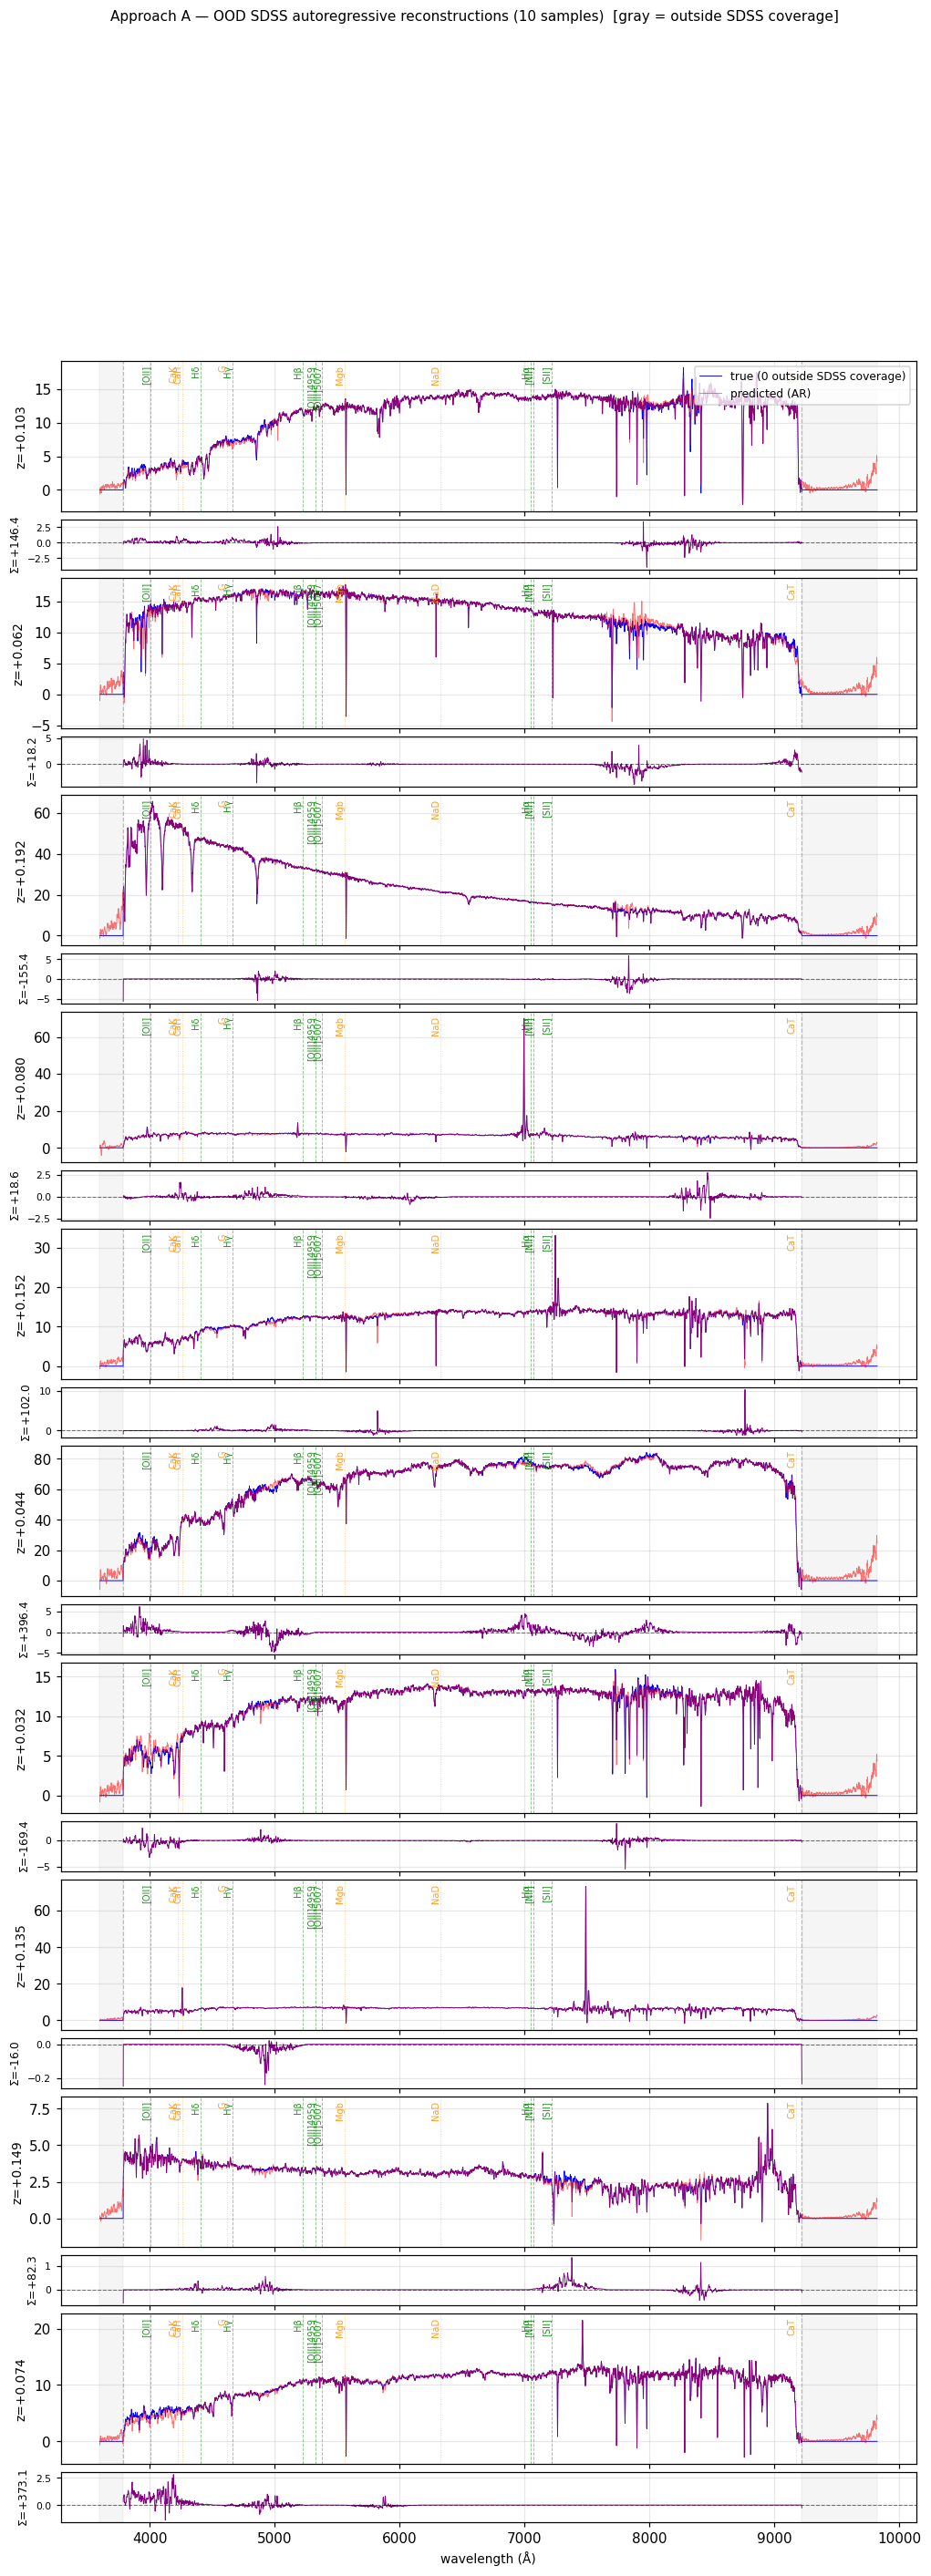

In [47]:
sdss_lo, sdss_hi = float(sdss_wave[0]), float(sdss_wave[-1])

# 2 rows per sample: flux row (height 3) + residual row (height 1)
height_ratios = [h for _ in range(N_OOD) for h in (3, 1)]
fig, axes = plt.subplots(
    N_OOD * 2, 1, figsize=(11, N_OOD * 2.8),
    gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.08},
)

for i in range(N_OOD):
    ax_f = axes[i * 2]      # flux row
    ax_r = axes[i * 2 + 1]  # residual row

    # both arrays are now on the canonical ref_wave grid (LATENT_GRID_SIZE pixels)
    true_s = to_sdss_grid(ood_true_flux[i])
    ar_s   = to_sdss_grid(ood_ar_flux[i])
    resid  = true_s - ar_s
    resid_sum = float(resid.sum())

    # --- flux row ---
    ax_f.plot(ref_wave, ood_true_flux[i], color='blue', lw=0.6,
              label='true (0 outside SDSS coverage)')
    ax_f.plot(ref_wave, ood_ar_flux[i],   color='red',  lw=0.6, alpha=0.55,
              label='predicted (AR)')
    ax_f.axvspan(desi_wave[0], sdss_lo,  alpha=0.08, color='gray')
    ax_f.axvspan(sdss_hi, desi_wave[-1], alpha=0.08, color='gray')
    ax_f.axvline(sdss_lo, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax_f.axvline(sdss_hi, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax_f.set_ylabel(f'z={ood_specs[i]["z"].item():+.3f}', fontsize=9)
    mark_lines(ax_f, z, float(desi_wave[0]), float(desi_wave[-1]))
    ax_f.set_xticklabels([])
    ax_f.grid(alpha=0.3)
    if i == 0:
        ax_f.legend(loc='upper right', fontsize=8)

    # --- residual row ---
    ax_r.plot(sdss_wave, resid, color='purple', lw=0.6)
    ax_r.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
    ax_r.axvspan(desi_wave[0], sdss_lo,  alpha=0.08, color='gray')
    ax_r.axvspan(sdss_hi, desi_wave[-1], alpha=0.08, color='gray')
    ax_r.set_ylabel(f'$\\Sigma$={resid_sum:+.1f}', fontsize=8, labelpad=4)
    ax_r.grid(alpha=0.3)
    ax_r.tick_params(axis='y', labelsize=7)
    if i < N_OOD - 1:
        ax_r.set_xticklabels([])

axes[-1].set_xlabel('wavelength (Å)', fontsize=9)
fig.suptitle(
    f'Approach {APPROACH.upper()} — OOD SDSS autoregressive reconstructions ({N_OOD} samples)  [gray = outside SDSS coverage]',
    y=1.005, fontsize=10,
)
plt.show()


## OOD Visualization 7 — SDSS redshift prediction (autoregressive)

AR-only redshift scatter for SDSS spectra. The model generates the redshift token first without any explicit z hint, so this tests whether spectral features from an OOD instrument are recognisable enough to recover the redshift.

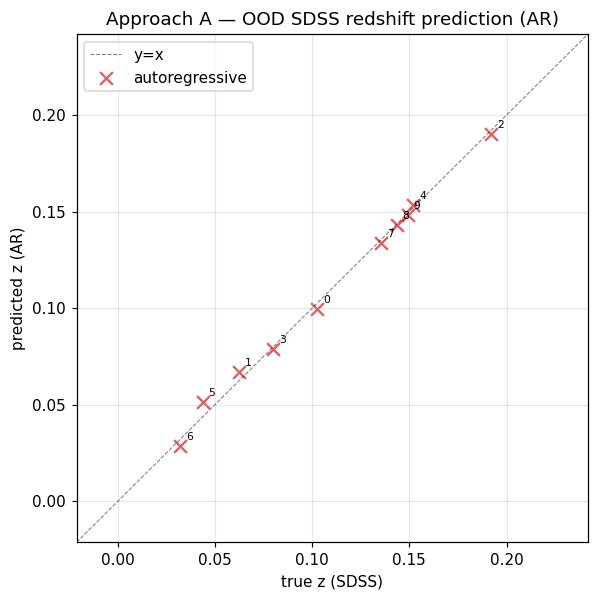

OOD SDSS — autoregressive MAE = 0.0026

  0: z_true=+0.1026  ar=+0.0995
  1: z_true=+0.0622  ar=+0.0668
  2: z_true=+0.1919  ar=+0.1903
  3: z_true=+0.0800  ar=+0.0790
  4: z_true=+0.1521  ar=+0.1536
  5: z_true=+0.0436  ar=+0.0514
  6: z_true=+0.0322  ar=+0.0288
  7: z_true=+0.1355  ar=+0.1335
  8: z_true=+0.1434  ar=+0.1428
  9: z_true=+0.1492  ar=+0.1485


In [21]:
ood_z_true = torch.stack([s['z'] for s in ood_specs]).float()

ood_ar_z_token = ood_generated[:, 1].cpu()
ood_ar_z_idx   = (ood_ar_z_token - REDSHIFT_TOKEN_OFFSET).clamp(0, z_tok.n_levels - 1)
ood_ar_z_pred  = torch.tensor([z_tok.decode(int(i)) for i in ood_ar_z_idx])

fig, ax = plt.subplots(figsize=(6, 6))
lim_lo = min(ood_z_true.min().item(), ood_ar_z_pred.min().item()) - 0.05
lim_hi = max(ood_z_true.max().item(), ood_ar_z_pred.max().item()) + 0.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=0.7, alpha=0.5, label='y=x')
ax.scatter(ood_z_true, ood_ar_z_pred, s=70, alpha=0.75, marker='x', label='autoregressive', c='C3')
for i in range(len(ood_z_true)):
    ax.annotate(str(i), (ood_z_true[i], ood_ar_z_pred[i]), fontsize=7,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('true z (SDSS)')
ax.set_ylabel('predicted z (AR)')
ax.set_title(f'Approach {APPROACH.upper()} — OOD SDSS redshift prediction (AR)')
ax.grid(alpha=0.3)
ax.legend()
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
plt.show()

print(f'OOD SDSS — autoregressive MAE = {(ood_ar_z_pred - ood_z_true).abs().mean():.4f}')
print()
for i in range(len(ood_z_true)):
    print(f'  {i}: z_true={ood_z_true[i]:+.4f}  ar={ood_ar_z_pred[i]:+.4f}')

## OOD Visualization 8 — SDSS vs DESI AR MSE comparison

AR MSE histogram comparing in-distribution DESI reconstructions against OOD SDSS. Higher SDSS MSE is expected — the gap measures how domain-specific the tokenizer + transformer representation is.

NameError: name 'ar_mse' is not defined

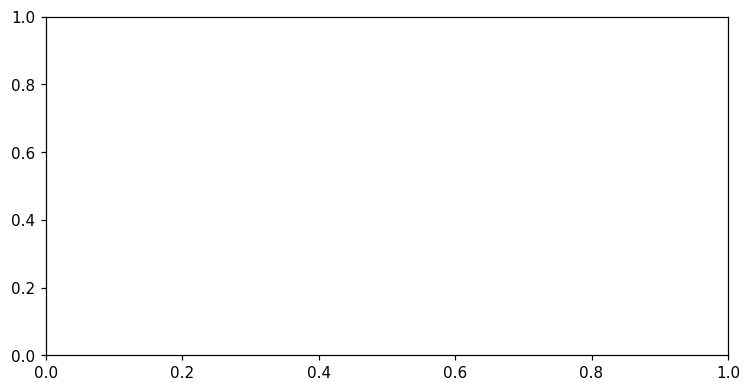

In [28]:
# Project both onto the common SDSS grid before computing MSE
ood_true_on_sdss = np.stack([to_sdss_grid(ood_true_flux[i]) for i in range(N_OOD)])
ood_ar_on_sdss   = np.stack([to_sdss_grid(ood_ar_flux[i])   for i in range(N_OOD)])
ood_ar_mse = ((ood_true_on_sdss - ood_ar_on_sdss)**2).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ar_mse,     bins=15, alpha=0.6, label=f'DESI AR (mean={ar_mse.mean():.3f})',     color='C1')
ax.hist(ood_ar_mse, bins=15, alpha=0.6, label=f'SDSS AR (mean={ood_ar_mse.mean():.3f})', color='C0')
ax.set_xlabel('per-spectrum MSE (autoregressive)')
ax.set_ylabel('count')
ax.set_title('OOD degradation: SDSS vs DESI \u2014 autoregressive MSE')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f'DESI AR MSE : mean={ar_mse.mean():.3f}')
print(f'SDSS AR MSE : mean={ood_ar_mse.mean():.3f}  ({ood_ar_mse.mean()/max(ar_mse.mean(),1e-9):.1f}x vs DESI)')


## What to look for

| signal | interpretation |
|---|---|
| TF and AR reconstructions look similar | model has actually learned spectroscopy |
| TF looks great, AR looks like noise | the teacher-forced number was inflated by the cross-attention copy — the model can't actually generate |
| Redshift scatter on `y=x` for Approach A | cross-attention copy works (expected) |
| Redshift scatter scattered for Approach B | the encoder isn't encoding redshift (the Phase 9 result) |
| Per-position accuracy flat-high for pos 1+, low at pos 0 | classic copy regime — needs encoder masking |
| Per-position accuracy declining toward the end of the sequence | error accumulation in AR, typical of language models |
| AR/TF MSE ratio = 1.0 | honest model |
| AR/TF MSE ratio >>1 (e.g. 10x+) | strong copy dependency |